<a href="https://colab.research.google.com/github/ankitkr104/Ankit.kr/blob/main/Capstone_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install silence_tensorflow
#This package helps suppress TensorFlow warnings and unnecessary logs, making the output cleaner and more readable.

In [6]:
# A function to avoid tensorflow warnings
from silence_tensorflow import silence_tensorflow
silence_tensorflow()

In [7]:
import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from termcolor import colored
import matplotlib.pyplot as plt
from keras.utils import plot_model
from tensorflow.keras import optimizers
from tensorflow.keras import models, layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
sns.set_style('darkgrid')
warnings.filterwarnings('ignore')

**DATA PREPERATION**

In [10]:
# prompt: CODE DOWNLOAD THIS DATASET FROM KAGGLE OF DIRECTORY kritikseth/fruit-and-vegetable-image-recognition

!kaggle datasets download -d swoyam2609/fresh-and-stale-classification


Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'


In [11]:
base_dir = '/content/drive/MyDrive'

In [12]:
train_dir = os.path.join(base_dir, '/content/drive/MyDrive/Train')
validation_dir = os.path.join(base_dir, '/content/drive/MyDrive/Test')
test_dir = os.path.join(base_dir, '/content/drive/MyDrive/Test')

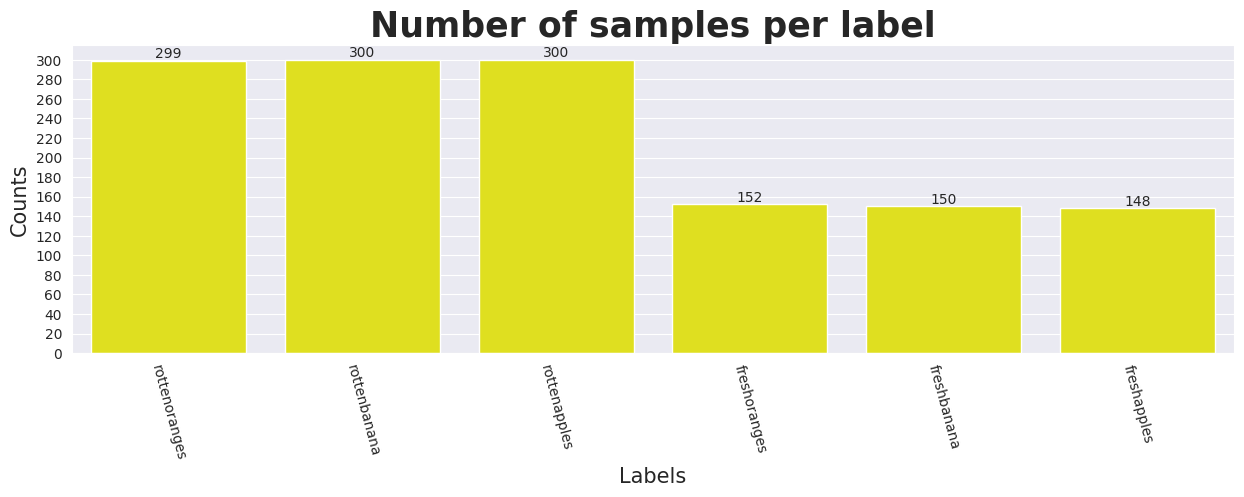

In [13]:
classes = [class_name for class_name in os.listdir(train_dir)]
count = []
for class_name in classes :
    count.append(len(os.listdir(os.path.join(train_dir, class_name))))

plt.figure(figsize=(15, 4))
ax = sns.barplot(x=classes, y=count, color='yellow')
plt.xticks(rotation=285)
for i in ax.containers:
    ax.bar_label(i,)
plt.title('Number of samples per label', fontsize=25, fontweight='bold')
plt.xlabel('Labels', fontsize=15)
plt.ylabel('Counts', fontsize=15)
plt.yticks(np.arange(0, 305, 20))
plt.show()

In [14]:
def num_of_classes(folder_dir, folder_name) :
    classes = [class_name for class_name in os.listdir(train_dir)]
    print(colored(f'number of classes in {folder_name} folder : {len(classes)}', 'blue', attrs=['bold']))

In [15]:
num_of_classes(train_dir, '/content/drive/MyDrive/Train')
num_of_classes(validation_dir, '/content/drive/MyDrive/Test')
num_of_classes(test_dir, '/content/drive/MyDrive/Test')

number of classes in /content/drive/MyDrive/Train folder : 6
number of classes in /content/drive/MyDrive/Test folder : 6
number of classes in /content/drive/MyDrive/Test folder : 6


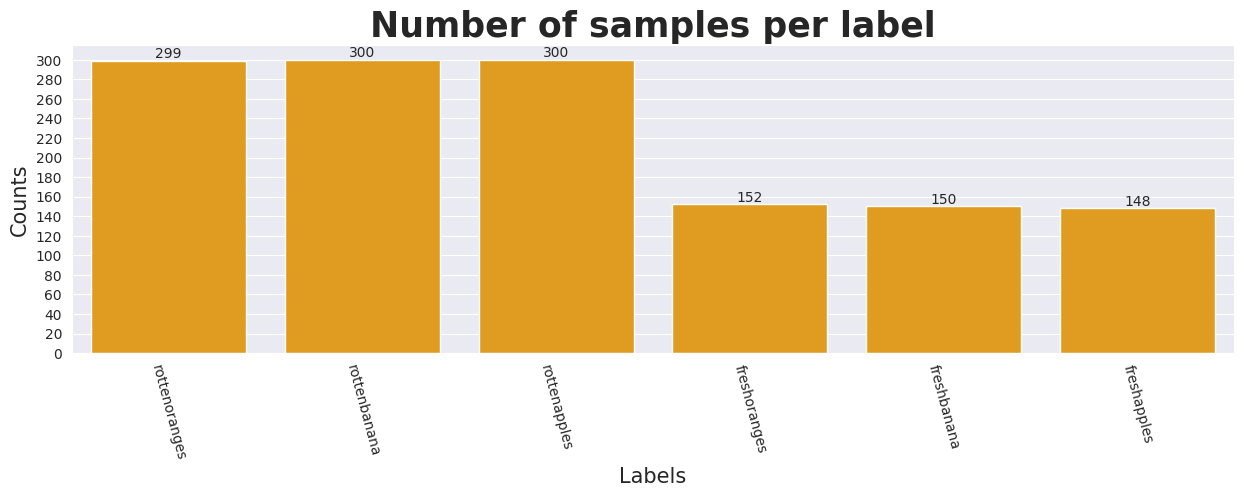

In [16]:
classes = [class_name for class_name in os.listdir(train_dir)]
count = []
for class_name in classes :
    count.append(len(os.listdir(os.path.join(train_dir, class_name))))

plt.figure(figsize=(15, 4))
ax = sns.barplot(x=classes, y=count, color='orange')
plt.xticks(rotation=285)
for i in ax.containers:
    ax.bar_label(i,)
plt.title('Number of samples per label', fontsize=25, fontweight='bold')
plt.xlabel('Labels', fontsize=15)
plt.ylabel('Counts', fontsize=15)
plt.yticks(np.arange(0, 305, 20))
plt.show()

In [17]:
def create_df(folder_path) :
    all_images = []
    for class_name in classes :
        class_path = os.path.join(folder_path, class_name)
        all_images.extend([(os.path.join(class_path, file_name), class_name) for file_name in os.listdir(class_path)])
    df = pd.DataFrame(all_images, columns=['file_path', 'label'])
    return df

In [18]:
def create_df(folder_path):
    """Creates a DataFrame with file paths and labels.

    This function now determines the classes directly from the provided folder path
    instead of relying on a global variable.

    Args:
        folder_path (str): The path to the folder containing the image data.

    Returns:
        pd.DataFrame: A DataFrame with columns 'file_path' and 'label'.
    """
    all_images = []
    # Get classes directly from the folder path
    classes = [class_name for class_name in os.listdir(folder_path)]
    for class_name in classes:
        class_path = os.path.join(folder_path, class_name)
        all_images.extend([(os.path.join(class_path, file_name), class_name) for file_name in os.listdir(class_path)])
    df = pd.DataFrame(all_images, columns=['file_path', 'label'])
    return df

In [19]:
train_df = create_df(train_dir)
validation_df = create_df(validation_dir)
test_df = create_df(test_dir)

In [20]:
print(colored(f'Number of samples in train : {len(train_df)}', 'blue', attrs=['bold']))
print(colored(f'Number of samples in validation : {len(validation_df)}', 'blue', attrs=['bold']))
print(colored(f'Number of samples test : {len(test_df)}', 'blue', attrs=['bold']))

Number of samples in train : 1349
Number of samples in validation : 1363
Number of samples test : 1363


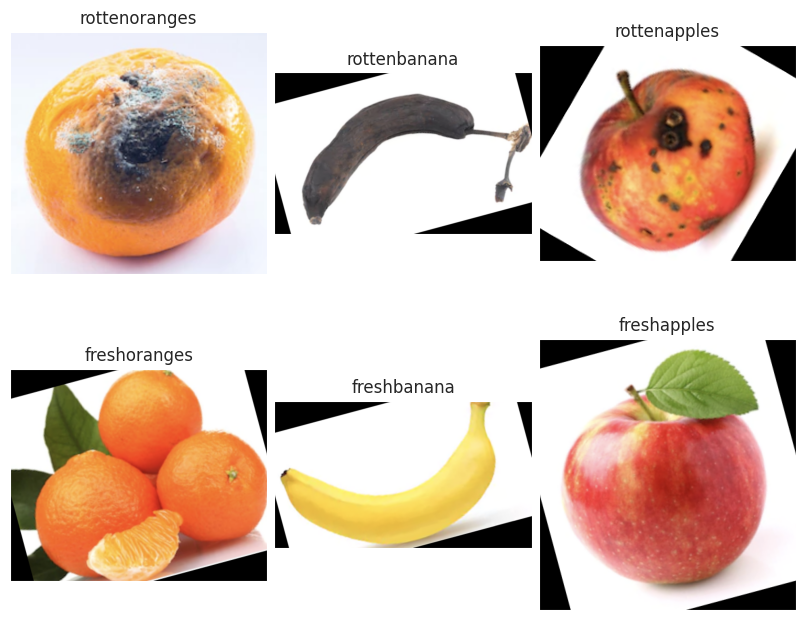

In [21]:
# Create a DataFrame with one Label of each category
df_unique = train_df.copy().drop_duplicates(subset=["label"]).reset_index()

# Display some pictures of the dataset
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(8, 7),
                        subplot_kw={'xticks': [], 'yticks': []})

# Limit the iteration to the number of unique labels
for i, ax in enumerate(axes.flat):
    # Break the loop if we've displayed all unique labels
    if i >= len(df_unique):
        break
    ax.imshow(plt.imread(df_unique.file_path[i]))
    ax.set_title(df_unique.label[i], fontsize=12)

plt.tight_layout(pad=0.5)
plt.show()

In [22]:
train_datagen = ImageDataGenerator(
    rescale=1./255,                 # Scaled images in range 0 to 1
    rotation_range=20,              # Rorate images by factor 20 degree
    width_shift_range=0.2,          # Shift images horizontally by up to 20% of their width
    height_shift_range=0.2,         # Shift images vertically by up to 20% of their width
    zoom_range=0.1,                 # Zoom in and out images by 10%
    horizontal_flip=True,           # Allow horizontal flipping
    shear_range=0.1,                # shear images by 10% their size
    fill_mode='nearest',            # fill unlocated pixels by nearest pixel
    )

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,             # Target data
    x_col='file_path',              # X column
    y_col='label',                  # y column
    target_size=(224, 224),         # Resize images  to
    color_mode='rgb',               # Color mode
    class_mode='categorical',       # type of model
    batch_size=32,
    shuffle=True,
    seed=42,

)

Found 1349 validated image filenames belonging to 6 classes.


In [23]:
# validation generator

validation_datagen = ImageDataGenerator(rescale=1./255,)

validation_generator = validation_datagen.flow_from_dataframe(
    dataframe=validation_df,
    x_col='file_path',
    y_col='label',
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    seed=42,
    shuffle=False
)

Found 1363 validated image filenames belonging to 6 classes.


In [24]:
test_datagen = ImageDataGenerator(rescale=1./255,)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='file_path',
    y_col='label',
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    seed=42,
    shuffle=False
)

Found 1363 validated image filenames belonging to 6 classes.


In [25]:
pre_trained_model = MobileNetV2(
    input_shape=(224, 224, 3),            # Input image size
    include_top=False,                    # model not include top layer
    weights='imagenet',                   # weights type
    pooling='avg'                         # type of pooling layer
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [26]:
pre_trained_model = MobileNetV2(
    input_shape=(224, 224, 3),            # Input image size
    include_top=False,                    # model not include top layer
    weights='imagenet',                   # weights type
    pooling='avg'                         # type of pooling layer
)

In [27]:
# Freeze all layers, except last layer
# The goal is to train just last layer of pre trained model

pre_trained_model.trainable = True
set_trainable = False

for layer in pre_trained_model.layers :
    if layer.name == 'block_16_expand' :
        set_trainable = True
    if set_trainable :
        layer.trainable = True
    else :
        layer.trainable = False

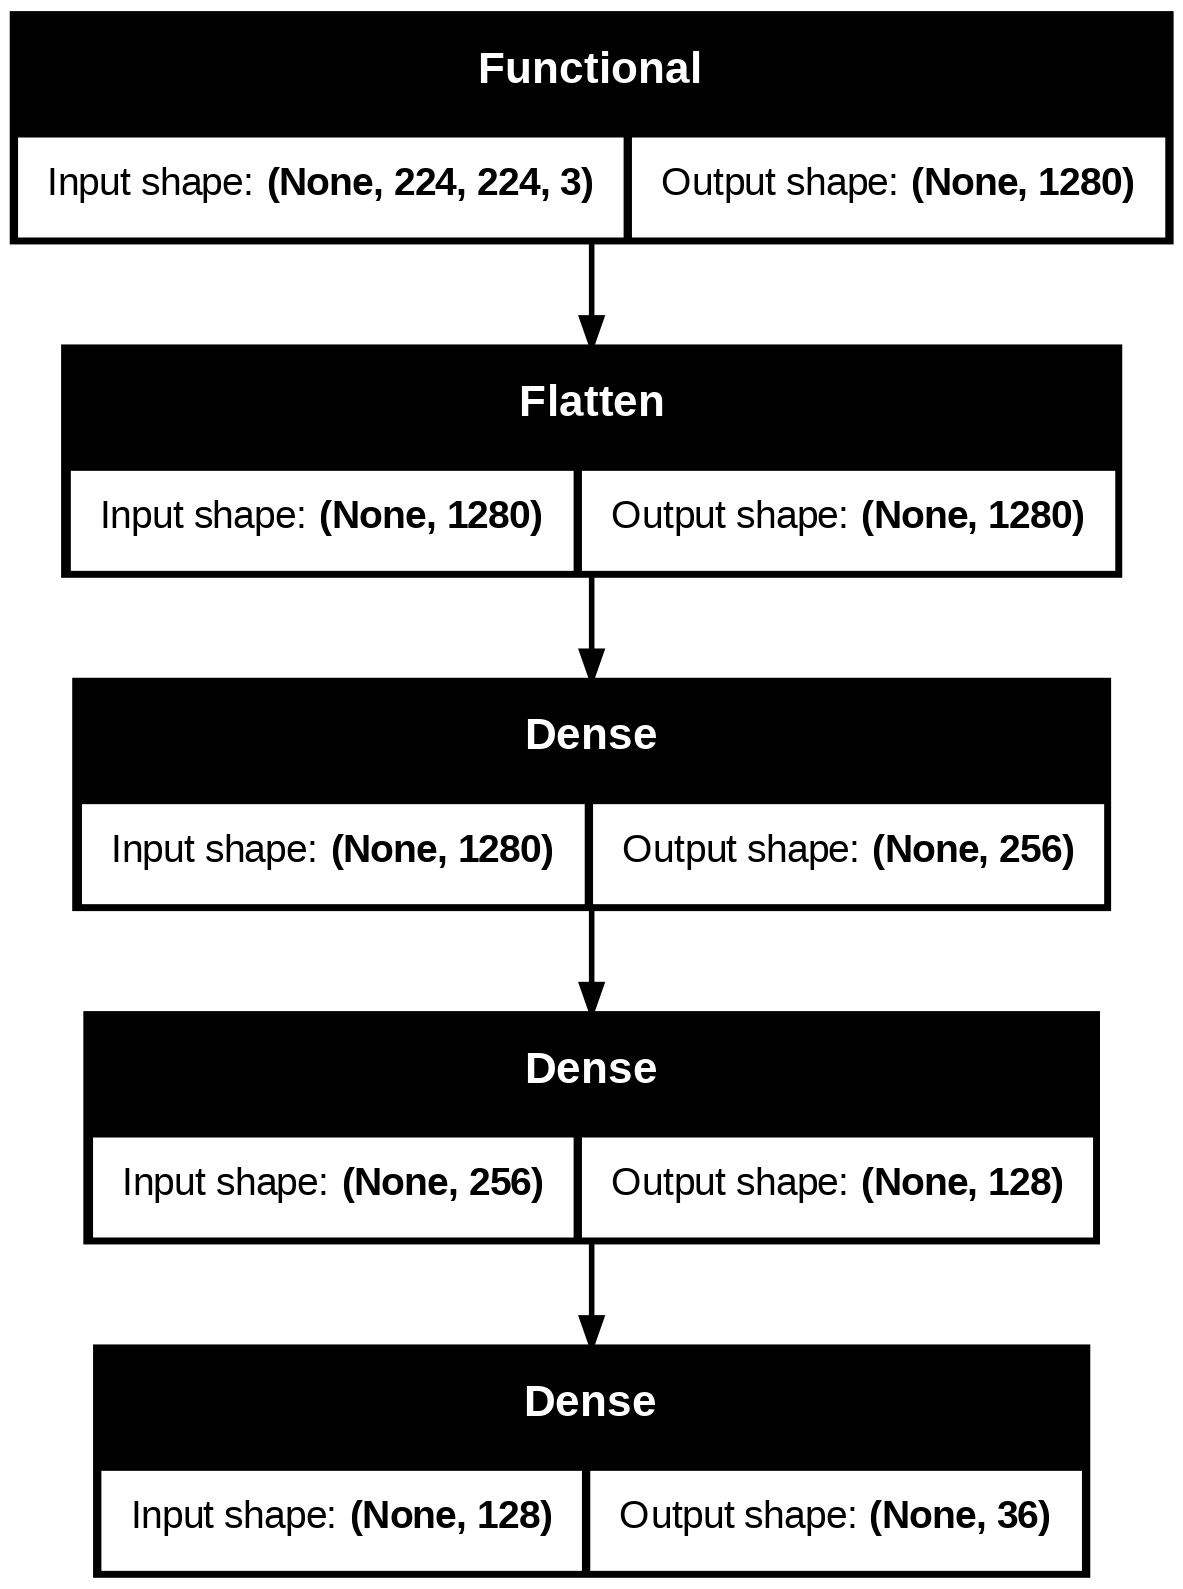

In [28]:
# Add custom layers on top of the base model
model = models.Sequential()
model.add(pre_trained_model)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(36, activation='softmax'))

# Build the model by specifying the input shape
# This is necessary since we haven't called fit() yet
model.build(input_shape=(None, 224, 224, 3)) # 'None' represents the batch size

plot_model(model, show_shapes=True, show_layer_names=False, dpi=200)

In [29]:
# Compile
model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
             loss='categorical_crossentropy',
             metrics=['accuracy'])

In [30]:
# Model CheckPoint
checkpoint_cb = ModelCheckpoint('MyModel.keras', save_best_only=True)

# Early Stoping
earlystop_cb = EarlyStopping(patience=10, restore_best_weights=True)

# ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

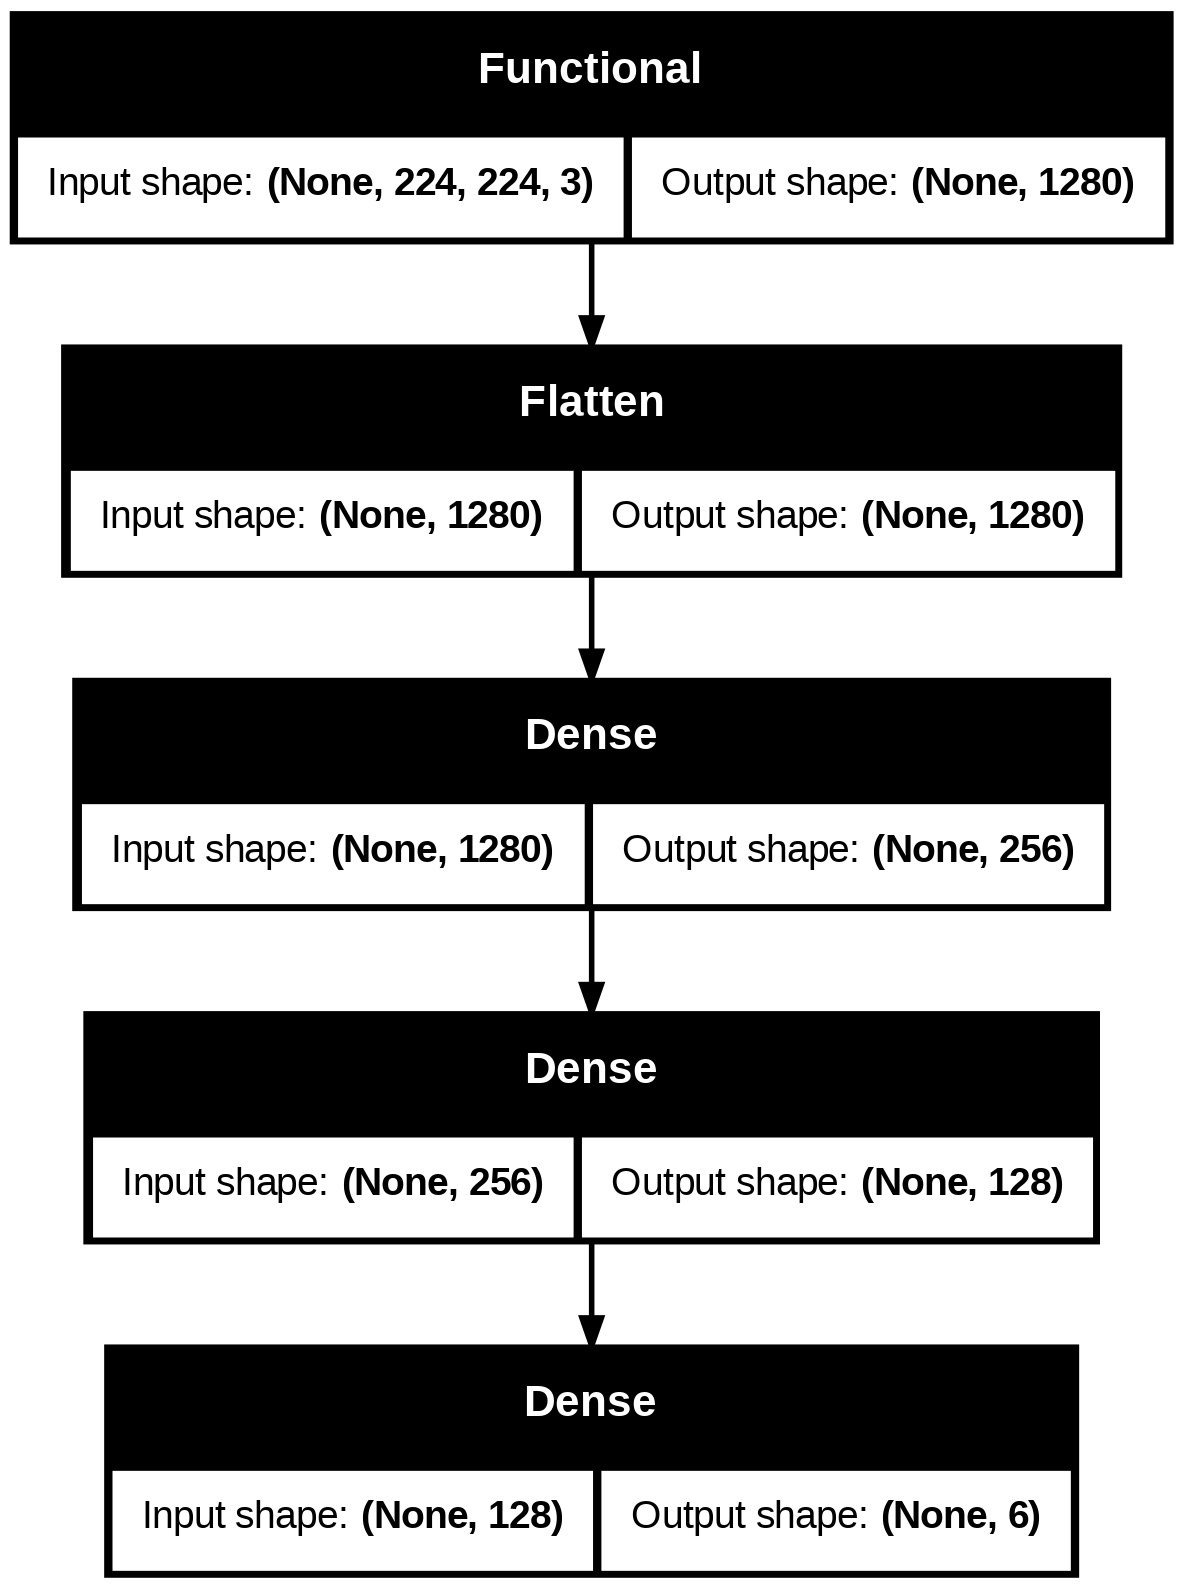

In [31]:
# Add custom layers on top of the base model
model = models.Sequential()
model.add(pre_trained_model)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(128, activation='relu'))
# Change the number of units in the final Dense layer to 14, or whatever the actual number of classes in your dataset is.
model.add(layers.Dense(6, activation='softmax')) # Assuming 6 classes

# Build the model by specifying the input shape
# This is necessary since we haven't called fit() yet
model.build(input_shape=(None, 224, 224, 3)) # 'None' represents the batch size

plot_model(model, show_shapes=True, show_layer_names=False, dpi=200)

In [32]:
# Compile
model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
             loss='categorical_crossentropy',
             metrics=['accuracy'])
print("Model compiled successfully!") # Add this line for verification

Model compiled successfully!


In [33]:
# Model CheckPoint
checkpoint_cb = ModelCheckpoint('MyModel.keras', save_best_only=True)

# Early Stoping
earlystop_cb = EarlyStopping(patience=10, restore_best_weights=True)

# ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Ensure validation_generator yields data by checking its contents
# For example, you can try iterating through it and printing a few samples:

# Print some samples from validation_generator
for i in range(5):
  X_val_sample, y_val_sample = next(validation_generator)
  print(f"Validation sample {i+1}: X_shape={X_val_sample.shape}, y_shape={y_val_sample.shape}")

# Fit the model
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=1,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr]
)

Validation sample 1: X_shape=(32, 224, 224, 3), y_shape=(32, 6)
Validation sample 2: X_shape=(32, 224, 224, 3), y_shape=(32, 6)
Validation sample 3: X_shape=(32, 224, 224, 3), y_shape=(32, 6)
Validation sample 4: X_shape=(32, 224, 224, 3), y_shape=(32, 6)
Validation sample 5: X_shape=(32, 224, 224, 3), y_shape=(32, 6)
43/43 ━━━━━━━━━━━━━━━━━━━━ 841s 19s/step - accuracy: 0.7679 - loss: 0.6458 - val_accuracy: 0.6016 - val_loss: 3.5229 - learning_rate: 0.0010


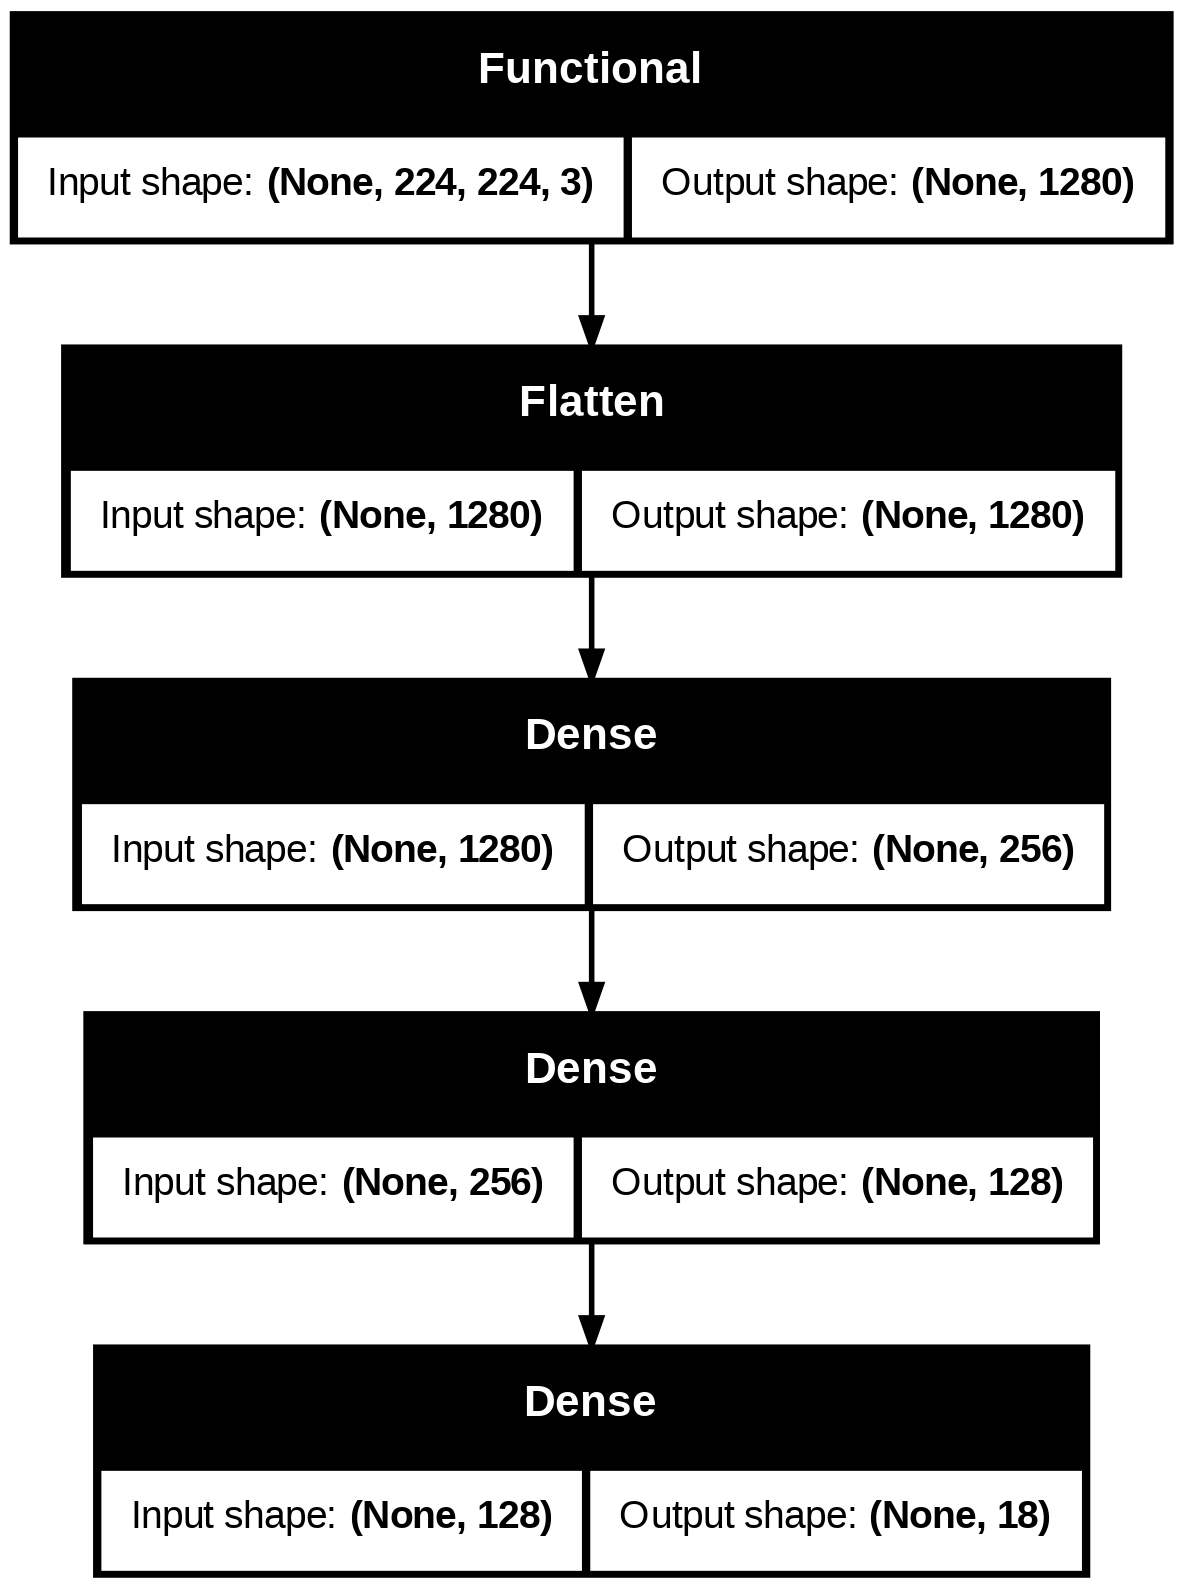

In [34]:
# Add custom layers on top of the base model
model = models.Sequential()
model.add(pre_trained_model)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(128, activation='relu'))
# Change the number of units in the output layer to 18
model.add(layers.Dense(18, activation='softmax')) # Changed from 36 to 18

# Build the model by specifying the input shape
# This is necessary since we haven't called fit() yet
model.build(input_shape=(None, 224, 224, 3)) # 'None' represents the batch size

plot_model(model, show_shapes=True, show_layer_names=False, dpi=200)

In [35]:
# checkpoint callback, save base model weights in "MyModel.keras".
# So, we should load it
best_model = models.load_model('MyModel.keras')

In [36]:
test_loss, test_acc = best_model.evaluate(test_generator)

print(colored(f'Test Loss : {round(test_loss, 3)}', 'green', attrs=['bold']))
print(colored(f'Test Accuracy : {round(test_acc, 3)}', 'green', attrs=['bold']))

43/43 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.7323 - loss: 2.4927
Test Loss : 3.523
Test Accuracy : 0.602


In [37]:
def evaluate_model_performance(model, val_generator, class_labels):
    """
    Evaluate the model's performance on the validation set and print the classification report.

    Parameters:
    - model: The trained model.
    - val_generator: Validation data generator.
    - class_labels: List of class names.

    Returns:
    - report: Classification report as a string.
    """

    # Getting all the true labels for the validation set
    true_labels = val_generator.classes

    # Get the class labels (names) from the generator
    class_labels = list(val_generator.class_indices.keys())

    # To get the predicted labels, we predict using the model
    predictions = model.predict(val_generator, steps=len(val_generator))

    # Take the argmax to get the predicted class indices.
    predicted_labels = np.argmax(predictions, axis=1)

    # Extracting true labels from the validation generator
    true_labels = val_generator.classes

    # Classification report
    report = classification_report(true_labels, predicted_labels, target_names=class_labels)
    print(report)
    print('\n')

    # Define a custom colormap
    colors = ["white", "#102C42"]
    # cmap_cm = LinearSegmentedColormap.from_list("cmap_cm", colors)

    # Confusion Matrix
    cm = confusion_matrix(true_labels, predicted_labels)

    # Plotting confusion matrix using seaborn
    plt.figure(figsize=(15,10))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

43/43 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step
               precision    recall  f1-score   support

  freshapples       0.74      0.96      0.83       162
  freshbanana       0.93      0.65      0.77       150
 freshoranges       1.00      0.22      0.36       148
 rottenapples       1.00      0.25      0.40       300
 rottenbanana       1.00      0.53      0.69       303
rottenoranges       0.38      1.00      0.55       300

     accuracy                           0.60      1363
    macro avg       0.84      0.60      0.60      1363
 weighted avg       0.83      0.60      0.59      1363





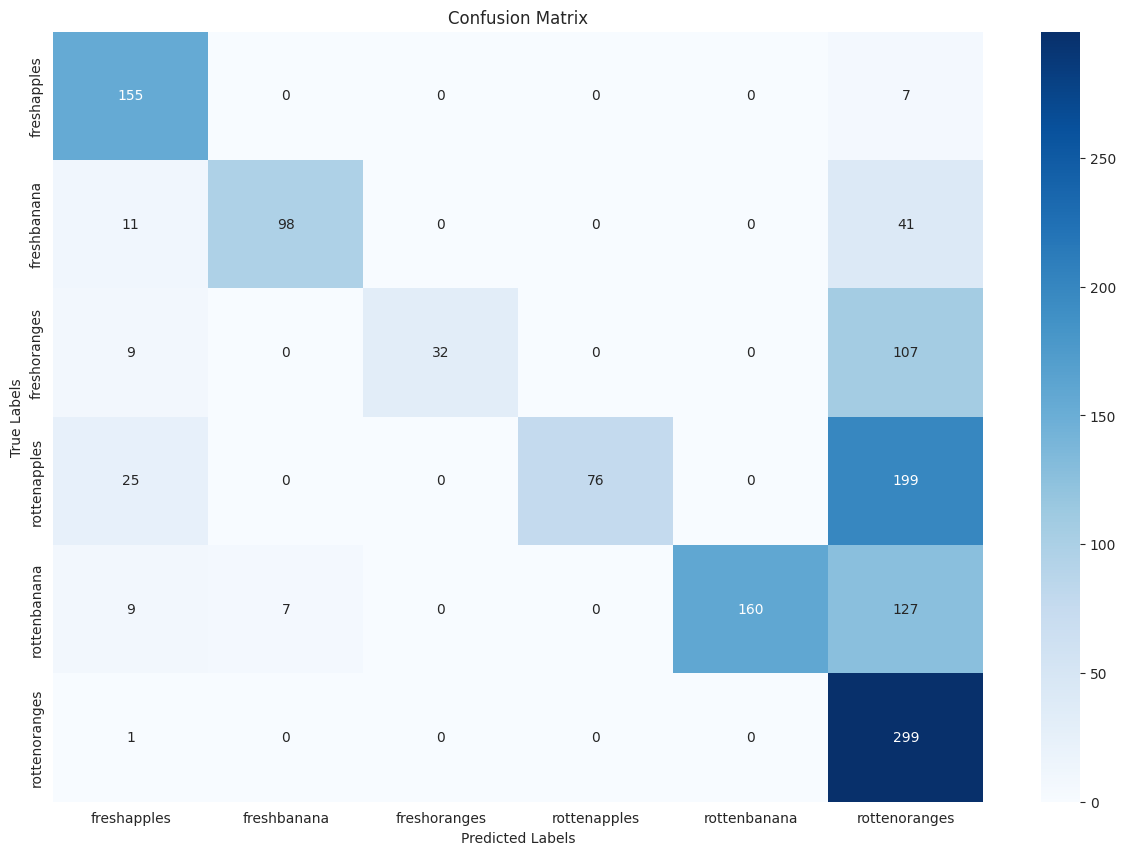

In [38]:
evaluate_model_performance(best_model, validation_generator, classes)

In [39]:
# adding starts


In [40]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [41]:
class ModelSetup:
    """
    🎯 PURPOSE: Load and prepare your trained model for testing
    📖 BEGINNER INFO: This part loads your saved model file and gets it ready for predictions
    """

    def __init__(self, model_path, class_labels):
        print("🚀 PART 1: MODEL SETUP")
        print("=" * 50)
        print("📖 What this does: Loads your trained model for testing")
        print("=" * 50)

        self.model_path = model_path
        self.class_labels = class_labels
        self.model = None

    def load_model(self):
        """Load the trained model"""
        try:
            print(f"📂 Loading model from: {self.model_path}")
            self.model = load_model(self.model_path, compile=False)
            self.model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
            print("✅ SUCCESS: Model loaded and ready!")
            print(f"🏷️  Model can classify: {len(self.class_labels)} classes")
            for i, label in enumerate(self.class_labels):
                print(f"   {i+1}. {label}")
            return True
        except Exception as e:
            print(f"❌ ERROR: Could not load model - {e}")
            return False

    def test_single_prediction(self, image_path):
        """Test model with a single image - good for beginners to start"""
        print(f"\n🧪 TESTING SINGLE IMAGE")
        print("-" * 30)

        if not self.model:
            print("❌ Model not loaded!")
            return

        # Load and process image
        img = cv2.imread(image_path)
        if img is None:
            print(f"❌ Could not load image: {image_path}")
            return

        # Prepare image for model
        img_resized = cv2.resize(img, (224, 224))
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
        img_normalized = img_rgb.astype('float32') / 255.0
        img_batch = np.expand_dims(img_normalized, axis=0)

        # Make prediction
        predictions = self.model.predict(img_batch, verbose=0)
        predicted_class_idx = np.argmax(predictions[0])
        confidence = float(predictions[0][predicted_class_idx])
        predicted_class = self.class_labels[predicted_class_idx]

        # Show results
        print(f"📸 Image: {os.path.basename(image_path)}")
        print(f"🎯 Prediction: {predicted_class}")
        print(f"📊 Confidence: {confidence:.3f} ({confidence*100:.1f}%)")

        # Show image with prediction
        plt.figure(figsize=(8, 6))
        plt.imshow(img_rgb)
        plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.3f}")
        plt.axis('off')
        plt.show()

print("✅ ModelSetup class defined!")

✅ ModelSetup class defined!


In [42]:
class BasicAccuracyCalculator:
    """
    🎯 PURPOSE: Calculate how often your model is correct
    📖 BEGINNER INFO: This shows you the percentage of correct predictions
    """

    def __init__(self, model, class_labels):
        print("\n📊 PART 2: BASIC ACCURACY CALCULATION")
        print("=" * 50)
        print("📖 What this does: Calculates how often your model is right")
        print("=" * 50)

        self.model = model
        self.class_labels = class_labels
        self.test_results = []

    def test_folder(self, folder_path, true_class_name):
        """Test all images in a folder"""
        print(f"🔍 Testing folder: {true_class_name}")

        if not os.path.exists(folder_path):
            print(f"❌ Folder not found: {folder_path}")
            return

        image_files = [f for f in os.listdir(folder_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        correct_count = 0
        total_count = len(image_files)

        print(f"📁 Found {total_count} images")

        for img_file in image_files:
            img_path = os.path.join(folder_path, img_file)

            # Process image
            img = cv2.imread(img_path)
            if img is None:
                continue

            img_resized = cv2.resize(img, (224, 224))
            img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
            img_normalized = img_rgb.astype('float32') / 255.0
            img_batch = np.expand_dims(img_normalized, axis=0)

            # Predict
            predictions = self.model.predict(img_batch, verbose=0)
            predicted_class_idx = np.argmax(predictions[0])
            predicted_class = self.class_labels[predicted_class_idx]
            confidence = float(predictions[0][predicted_class_idx])

            # Check if correct
            is_correct = predicted_class == true_class_name
            if is_correct:
                correct_count += 1

            # Store result
            self.test_results.append({
                'image_path': img_path,
                'true_class': true_class_name,
                'predicted_class': predicted_class,
                'confidence': confidence,
                'is_correct': is_correct
            })

        accuracy = correct_count / total_count if total_count > 0 else 0
        print(f"✅ Correct: {correct_count}/{total_count}")
        print(f"📊 Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

        return accuracy

    def calculate_overall_accuracy(self):
        """Calculate accuracy across all tested images"""
        if not self.test_results:
            print("❌ No test results available!")
            return

        total_images = len(self.test_results)
        correct_images = sum(1 for result in self.test_results if result['is_correct'])
        overall_accuracy = correct_images / total_images

        print(f"\n🎯 OVERALL RESULTS:")
        print(f"📊 Total Images Tested: {total_images}")
        print(f"✅ Correct Predictions: {correct_images}")
        print(f"❌ Wrong Predictions: {total_images - correct_images}")
        print(f"🏆 OVERALL ACCURACY: {overall_accuracy:.3f} ({overall_accuracy*100:.1f}%)")

        # Simple accuracy interpretation
        if overall_accuracy >= 0.9:
            print("🌟 EXCELLENT! Your model is very accurate!")
        elif overall_accuracy >= 0.8:
            print("👍 GOOD! Your model works well!")
        elif overall_accuracy >= 0.7:
            print("⚠️  OKAY! Your model needs some improvement!")
        else:
            print("❌ POOR! Your model needs significant improvement!")

print("✅ BasicAccuracyCalculator class defined!")

✅ BasicAccuracyCalculator class defined!


In [43]:
class ClassAccuracyAnalyzer:
    """
    🎯 PURPOSE: See which classes your model predicts best and worst
    📖 BEGINNER INFO: This shows accuracy for each fruit/vegetable type
    """

    def __init__(self, test_results, class_labels):
        print("\n📈 PART 3: ACCURACY BY CLASS")
        print("=" * 50)
        print("📖 What this does: Shows which classes your model handles best/worst")
        print("=" * 50)

        self.test_results = test_results
        self.class_labels = class_labels

    def analyze_per_class_accuracy(self):
        """Calculate accuracy for each class"""
        class_stats = {}

        # Initialize stats for each class
        for class_name in self.class_labels:
            class_stats[class_name] = {'correct': 0, 'total': 0, 'accuracy': 0}

        # Count correct/total for each class
        for result in self.test_results:
            true_class = result['true_class']
            is_correct = result['is_correct']

            class_stats[true_class]['total'] += 1
            if is_correct:
                class_stats[true_class]['correct'] += 1

        # Calculate accuracies
        for class_name in class_stats:
            total = class_stats[class_name]['total']
            correct = class_stats[class_name]['correct']
            if total > 0:
                class_stats[class_name]['accuracy'] = correct / total

        # Display results
        print("🏆 ACCURACY BY CLASS:")
        print("-" * 40)

        # Sort by accuracy (best to worst)
        sorted_classes = sorted(class_stats.items(), key=lambda x: x[1]['accuracy'], reverse=True)

        for class_name, stats in sorted_classes:
            accuracy = stats['accuracy']
            correct = stats['correct']
            total = stats['total']

            # Add emoji based on performance
            if accuracy >= 0.9:
                emoji = "🟢"  # Green - Excellent
            elif accuracy >= 0.8:
                emoji = "🟡"  # Yellow - Good
            elif accuracy >= 0.7:
                emoji = "🟠"  # Orange - Okay
            else:
                emoji = "🔴"  # Red - Poor

            print(f"{emoji} {class_name:15}: {accuracy:.3f} ({accuracy*100:5.1f}%) - {correct:2d}/{total:2d}")

        return class_stats

    def create_class_accuracy_chart(self, class_stats):
        """Create a visual chart of class accuracies"""
        print(f"\n📊 Creating Class Accuracy Chart...")

        # Prepare data for plotting
        classes = list(class_stats.keys())
        accuracies = [class_stats[cls]['accuracy'] for cls in classes]

        # Create bar chart
        plt.figure(figsize=(12, 6))
        bars = plt.bar(classes, accuracies)

        # Color bars based on accuracy
        for bar, accuracy in zip(bars, accuracies):
            if accuracy >= 0.9:
                bar.set_color('green')
            elif accuracy >= 0.8:
                bar.set_color('gold')
            elif accuracy >= 0.7:
                bar.set_color('orange')
            else:
                bar.set_color('red')

        # Add value labels on bars
        for bar, accuracy in zip(bars, accuracies):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{accuracy:.2f}\n({accuracy*100:.0f}%)',
                    ha='center', va='bottom', fontsize=10)

        plt.title('🎯 Model Accuracy by Class', fontsize=16, fontweight='bold')
        plt.xlabel('Classes', fontsize=12)
        plt.ylabel('Accuracy', fontsize=12)
        plt.ylim(0, 1.1)
        plt.xticks(rotation=45)
        plt.grid(axis='y', alpha=0.3)

        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='green', label='Excellent (90%+)'),
            Patch(facecolor='gold', label='Good (80-89%)'),
            Patch(facecolor='orange', label='Okay (70-79%)'),
            Patch(facecolor='red', label='Poor (<70%)')
        ]
        plt.legend(handles=legend_elements, loc='upper right')

        plt.tight_layout()
        plt.show()

print("✅ ClassAccuracyAnalyzer class defined!")

✅ ClassAccuracyAnalyzer class defined!


In [44]:
class WrongPredictionAnalyzer:
    """
    🎯 PURPOSE: Understand why your model makes mistakes
    📖 BEGINNER INFO: This shows which mistakes your model makes most often
    """

    def __init__(self, test_results):
        print("\n❌ PART 4: WRONG PREDICTIONS ANALYSIS")
        print("=" * 50)
        print("📖 What this does: Shows you the mistakes your model makes")
        print("=" * 50)

        self.test_results = test_results
        self.wrong_predictions = [r for r in test_results if not r['is_correct']]

    def analyze_common_mistakes(self):
        """Find the most common mistakes"""
        if not self.wrong_predictions:
            print("🎉 AMAZING! No wrong predictions found!")
            return

        print(f"📊 Total Wrong Predictions: {len(self.wrong_predictions)}")
        print(f"📊 Total Test Images: {len(self.test_results)}")

        # Count mistake patterns
        mistake_patterns = {}
        for result in self.wrong_predictions:
            true_class = result['true_class']
            predicted_class = result['predicted_class']
            pattern = f"{true_class} → {predicted_class}"

            if pattern not in mistake_patterns:
                mistake_patterns[pattern] = []
            mistake_patterns[pattern].append(result)

        # Sort by frequency
        sorted_mistakes = sorted(mistake_patterns.items(), key=lambda x: len(x[1]), reverse=True)

        print(f"\n🔄 MOST COMMON MISTAKES:")
        print("-" * 40)

        for i, (pattern, mistakes) in enumerate(sorted_mistakes[:5], 1):
            count = len(mistakes)
            percentage = (count / len(self.wrong_predictions)) * 100
            avg_confidence = np.mean([m['confidence'] for m in mistakes])

            print(f"{i}. {pattern}")
            print(f"   📊 Count: {count} times ({percentage:.1f}% of all mistakes)")
            print(f"   🎯 Avg Confidence: {avg_confidence:.3f}")
            print()

        return sorted_mistakes

    def show_mistake_examples(self, mistake_patterns, max_examples=6):
        """Show visual examples of mistakes"""
        print(f"🖼️  Showing examples of common mistakes...")

        # Get examples from top mistake patterns
        examples = []
        for pattern, mistakes in mistake_patterns[:3]:  # Top 3 mistake types
            examples.extend(mistakes[:2])  # 2 examples each

        if len(examples) > max_examples:
            examples = examples[:max_examples]

        if not examples:
            return

        # Create subplot grid
        rows = 2
        cols = 3
        fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
        fig.suptitle('🚨 Common Mistake Examples', fontsize=16, fontweight='bold')
        axes = axes.flatten()

        for i, example in enumerate(examples):
            if i >= len(axes):
                break

            # Load and display image
            img_path = example['image_path']
            img = cv2.imread(img_path)
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[i].imshow(img_rgb)

                # Create title with mistake info
                true_class = example['true_class']
                pred_class = example['predicted_class']
                confidence = example['confidence']

                title = f"Should be: {true_class}\nModel said: {pred_class}\nConfidence: {confidence:.2f}"
                axes[i].set_title(title, fontsize=10, color='red')
                axes[i].axis('off')

        # Hide unused subplots
        for i in range(len(examples), len(axes)):
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()

print("✅ WrongPredictionAnalyzer class defined!")

✅ WrongPredictionAnalyzer class defined!


In [45]:
class ConfusionMatrixVisualizer:
    """
    🎯 PURPOSE: Create a visual map of all prediction patterns
    📖 BEGINNER INFO: This shows which classes get confused with each other
    """

    def __init__(self, test_results, class_labels):
        print("\n📊 PART 5: CONFUSION MATRIX")
        print("=" * 50)
        print("📖 What this does: Creates a visual map showing prediction patterns")
        print("📖 How to read: Rows = True class, Columns = Predicted class")
        print("📖 Perfect model = only diagonal boxes filled")
        print("=" * 50)

        self.test_results = test_results
        self.class_labels = class_labels

    def create_confusion_matrix(self):
        """Create and display confusion matrix"""
        # Prepare data
        true_labels = []
        predicted_labels = []

        for result in self.test_results:
            true_labels.append(result['true_class'])
            predicted_labels.append(result['predicted_class'])

        # Create confusion matrix
        cm = confusion_matrix(true_labels, predicted_labels, labels=self.class_labels)

        # Create visualization
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=self.class_labels, yticklabels=self.class_labels,
                   cbar_kws={'label': 'Number of Predictions'})

        plt.title('🎯 Confusion Matrix\n(How often each class gets predicted as what)',
                 fontsize=14, fontweight='bold')
        plt.xlabel('Predicted Class', fontsize=12)
        plt.ylabel('True Class', fontsize=12)
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)

        # Add explanation text
        plt.figtext(0.02, 0.02,
                   "💡 How to read: Numbers on diagonal = correct predictions\n" +
                   "Numbers off diagonal = mistakes (true class → predicted class)",
                   fontsize=10, style='italic')

        plt.tight_layout()
        plt.show()

        # Explain the matrix
        self.explain_confusion_matrix(cm)

    def explain_confusion_matrix(self, cm):
        """Explain what the confusion matrix shows"""
        print(f"\n🔍 CONFUSION MATRIX EXPLANATION:")
        print("-" * 40)

        # Find biggest confusions (off-diagonal)
        confusions = []
        for i, true_class in enumerate(self.class_labels):
            for j, pred_class in enumerate(self.class_labels):
                if i != j and cm[i][j] > 0:  # Off-diagonal entries
                    confusions.append((true_class, pred_class, cm[i][j]))

        # Sort by confusion count
        confusions.sort(key=lambda x: x[2], reverse=True)

        if confusions:
            print("🚨 BIGGEST CONFUSIONS:")
            for true_class, pred_class, count in confusions[:5]:
                print(f"   {true_class} mistaken as {pred_class}: {count} times")
        else:
            print("🎉 No confusions found - perfect predictions!")

print("✅ ConfusionMatrixVisualizer class defined!")

✅ ConfusionMatrixVisualizer class defined!


In [46]:
class BeginnerMLAnalyzer:
    """
    🎯 PURPOSE: Run all analysis parts in order
    📖 BEGINNER INFO: This coordinates all the different analysis parts
    """

    def __init__(self):
        print("🚀 WELCOME TO BEGINNER ML MODEL ANALYZER!")
        print("=" * 60)
        print("This tool will help you understand your model's performance")
        print("We'll go through 6 different parts step by step")
        print("=" * 60)

    def run_complete_analysis(self, model_path, test_data_path, class_labels):
        """Run all analysis parts"""

        # PART 1: Load Model
        setup = ModelSetup(model_path, class_labels)
        if not setup.load_model():
            return

        # PART 2: Basic Accuracy
        accuracy_calc = BasicAccuracyCalculator(setup.model, class_labels)

        # Test each class folder
        for class_name in class_labels:
            class_folder = os.path.join(test_data_path, class_name)
            if os.path.exists(class_folder):
                accuracy_calc.test_folder(class_folder, class_name)
            else:
                print(f"⚠️  Warning: Folder {class_folder} not found")

        # Calculate overall accuracy
        accuracy_calc.calculate_overall_accuracy()

        # PART 3: Class Analysis
        class_analyzer = ClassAccuracyAnalyzer(accuracy_calc.test_results, class_labels)
        class_stats = class_analyzer.analyze_per_class_accuracy()
        class_analyzer.create_class_accuracy_chart(class_stats)

        # PART 4: Wrong Predictions
        wrong_analyzer = WrongPredictionAnalyzer(accuracy_calc.test_results)
        mistake_patterns = wrong_analyzer.analyze_common_mistakes()
        if mistake_patterns:
            wrong_analyzer.show_mistake_examples(mistake_patterns)

        # PART 5: Confusion Matrix
        confusion_viz = ConfusionMatrixVisualizer(accuracy_calc.test_results, class_labels)
        confusion_viz.create_confusion_matrix()

        print("\n🎉 ANALYSIS COMPLETE!")
        print("=" * 50)
        print("You now have a complete picture of your model's performance!")
        print("Use this information to improve your model and training data.")
        print("=" * 50)

print("✅ BeginnerMLAnalyzer class defined!")

✅ BeginnerMLAnalyzer class defined!


In [47]:
# ==================================================================================
# 🚀 CONFIGURATION - CHANGE THESE SETTINGS FOR YOUR MODEL
# ==================================================================================

# 📝 UPDATE THESE PATHS AND SETTINGS FOR YOUR MODEL
model_path = 'my_fruit_vegetable_model.h5'  # Path to your saved model

# Your class names (must match training)
class_labels = ['freshapples', 'freshbanana', 'freshoranges',
               'rottenapples', 'rottenbanana', 'rottenoranges']

# Path to test data (should have subfolders for each class)
test_data_path = '/content/drive/MyDrive/Test'


print("🔧 Configuration set!")
print(f"📂 Model path: {model_path}")
print(f"📁 Test data path: {test_data_path}")
print(f"🏷️  Classes: {class_labels}")

🔧 Configuration set!
📂 Model path: my_fruit_vegetable_model.h5
📁 Test data path: /content/drive/MyDrive/Test
🏷️  Classes: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']


In [48]:
# ==================================================================================
# 🚀 RUN THE COMPLETE ANALYSIS
# ==================================================================================

# Create and run the analyzer
analyzer = BeginnerMLAnalyzer()
analyzer.run_complete_analysis(model_path, test_data_path, class_labels)

🚀 WELCOME TO BEGINNER ML MODEL ANALYZER!
This tool will help you understand your model's performance
We'll go through 6 different parts step by step
🚀 PART 1: MODEL SETUP
📖 What this does: Loads your trained model for testing
📂 Loading model from: my_fruit_vegetable_model.h5
❌ ERROR: Could not load model - [Errno 2] Unable to synchronously open file (unable to open file: name = 'my_fruit_vegetable_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
The predicted class for the image is: rottenbanana


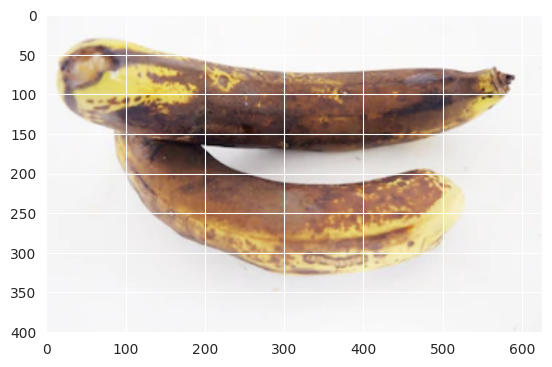

In [49]:
import numpy as np
from tensorflow.keras.preprocessing import image  # Import the image module
import matplotlib.pyplot as plt # Import matplotlib.pyplot

def predict_image_class(image_path):
  """
  Predicts the class of an image using the best_model.

  Args:
    image_path: The path to the image file.

  Returns:
    The predicted class label.
  """
  img_width, img_height = 224, 224  # Replace with the input size of your model

  img = image.load_img(image_path, target_size=(img_width, img_height))
  img = image.img_to_array(img)
  img = np.expand_dims(img, axis=0)
  img = img / 255.

  predictions = best_model.predict(img)
  predicted_class_index = np.argmax(predictions[0])
  predicted_class_label = list(train_generator.class_indices.keys())[predicted_class_index]

  return predicted_class_label


# Example usage:
image_path = '/content/drive/MyDrive/Train/rottenbanana/b_r277.png'
print_img = image.load_img(image_path) # Load the image before displaying it
plt.imshow(print_img)
predicted_class = predict_image_class(image_path)
print(f"The predicted class for the image is: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
The predicted class for the image is: freshbanana


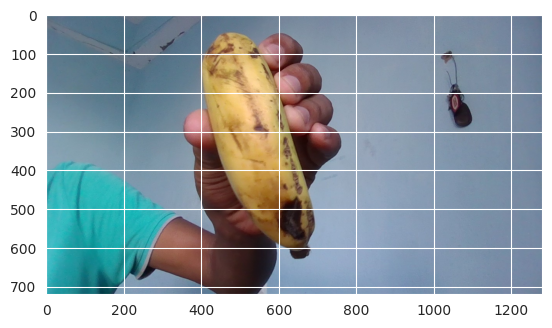

In [50]:
image_path = '/content/drive/MyDrive/Test/freshbanana/WIN_20250628_16_51_21_Pro.jpg'
print_img = image.load_img(image_path)
plt.imshow(print_img)
predicted_class = predict_image_class(image_path)
print(f"The predicted class for the image is: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
The predicted class for the image is: freshoranges


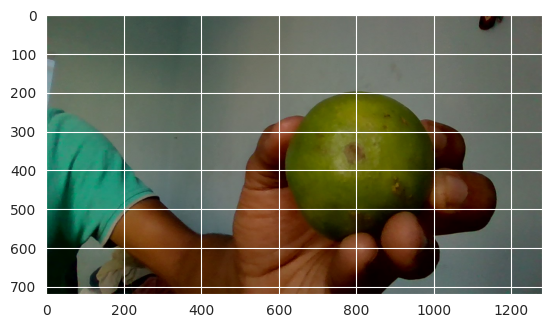

In [51]:
image_path = '/content/drive/MyDrive/Test/freshoranges/WIN_20250628_18_07_08_Pro.jpg'
print_img = image.load_img(image_path)
plt.imshow(print_img)
predicted_class = predict_image_class(image_path)
print(f"The predicted class for the image is: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
The predicted class for the image is: rottenapples


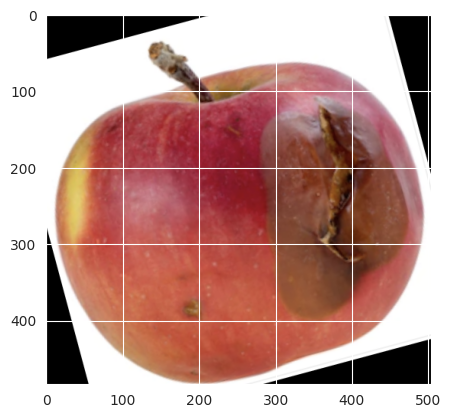

In [52]:
image_path = '/content/drive/MyDrive/Test/rottenapples/a_r001.png'
print_img = image.load_img(image_path)
plt.imshow(print_img)
predicted_class = predict_image_class(image_path)
print(f"The predicted class for the image is: {predicted_class}")

In [53]:
# export the best_model which is trained to save offline

best_model.save('my_fruit_vegetable_model.h5')
!zip -r my_fruit_vegetable_model.zip my_fruit_vegetable_model.h5
from google.colab import files
files.download('my_fruit_vegetable_model.zip')


  adding: my_fruit_vegetable_model.h5 (deflated 9%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
The predicted class for the image is: freshapples


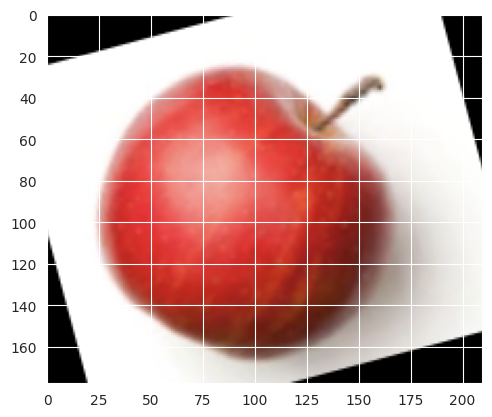

In [54]:
image_path = '/content/drive/MyDrive/Train/freshapples/a_f060.png'
print_img = image.load_img(image_path)
plt.imshow(print_img)
predicted_class = predict_image_class(image_path)
print(f"The predicted class for the image is: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
The predicted class for the image is: rottenapples


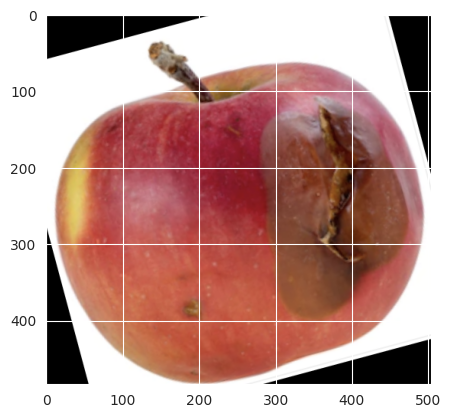

In [55]:
image_path = '/content/drive/MyDrive/Test/rottenapples/a_r001.png'
print_img = image.load_img(image_path)
plt.imshow(print_img)
predicted_class = predict_image_class(image_path)
print(f"The predicted class for the image is: {predicted_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
The predicted class for the image is: rottenoranges


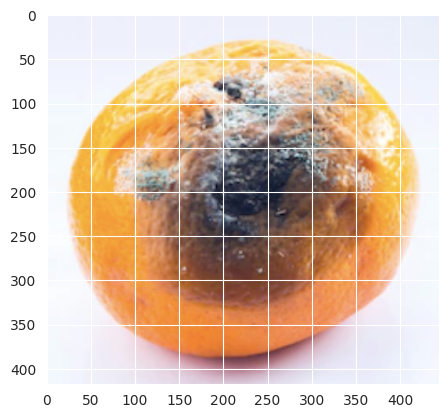

In [56]:
image_path = '/content/drive/MyDrive/Train/rottenoranges/vertical_flip_Screen Shot 2018-06-12 at 11.46.56 PM.png'
print_img = image.load_img(image_path)
plt.imshow(print_img)
predicted_class = predict_image_class(image_path)
print(f"The predicted class for the image is: {predicted_class}")

Loading model...
Model loaded!
Predicted: rottenapples
Confidence: 0.903


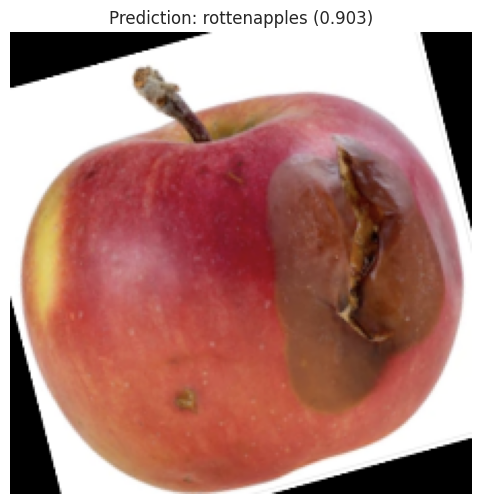

In [57]:
# Test 1: Load and test model
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Load model
print("Loading model...")
model = load_model('my_fruit_vegetable_model.h5', compile=False)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("Model loaded!")

# Test with one of your existing images
test_image = '/content/drive/MyDrive/Test/rottenapples/a_r001.png'

if os.path.exists(test_image):
    # Load and preprocess
    img = cv2.imread(test_image)
    img_resized = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    img_normalized = img_rgb.astype('float32') / 255.0
    img_batch = np.expand_dims(img_normalized, axis=0)

    # Predict
    predictions = model.predict(img_batch, verbose=0)
    class_labels = ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']

    predicted_class_index = np.argmax(predictions[0])
    confidence = float(predictions[0][predicted_class_index])
    predicted_class = class_labels[predicted_class_index]

    print(f"Predicted: {predicted_class}")
    print(f"Confidence: {confidence:.3f}")

    # Show image
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {predicted_class} ({confidence:.3f})")
    plt.axis('off')
    plt.show()
else:
    print("Test image not found. Please check the path.")

Loading model...
✅ Model loaded successfully!

Processing image: WIN_20250628_18_05_32_Pro.jpg
Making prediction...

🎯 TOP PREDICTION: freshoranges
📊 Confidence: 0.857 (85.7%)
📈 Assessment: High Confidence 🟡

DETAILED PREDICTION ANALYSIS
1. freshoranges    | 0.857 (85.7%) | █████████████████░░░ 🟡
   → High Confidence
2. rottenoranges   | 0.121 (12.1%) | ██░░░░░░░░░░░░░░░░░░ ⚫
3. freshapples     | 0.023 (2.3%) | ░░░░░░░░░░░░░░░░░░░░ ⚫
4. rottenapples    | 0.000 (0.0%) | ░░░░░░░░░░░░░░░░░░░░ ⚫
5. freshbanana     | 0.000 (0.0%) | ░░░░░░░░░░░░░░░░░░░░ ⚫
6. rottenbanana    | 0.000 (0.0%) | ░░░░░░░░░░░░░░░░░░░░ ⚫

📊 ADDITIONAL METRICS:
   Prediction Uncertainty: 0.264 (lower is better)
   Entropy Score: 0.473
   Overall Reliability: HIGH ✅


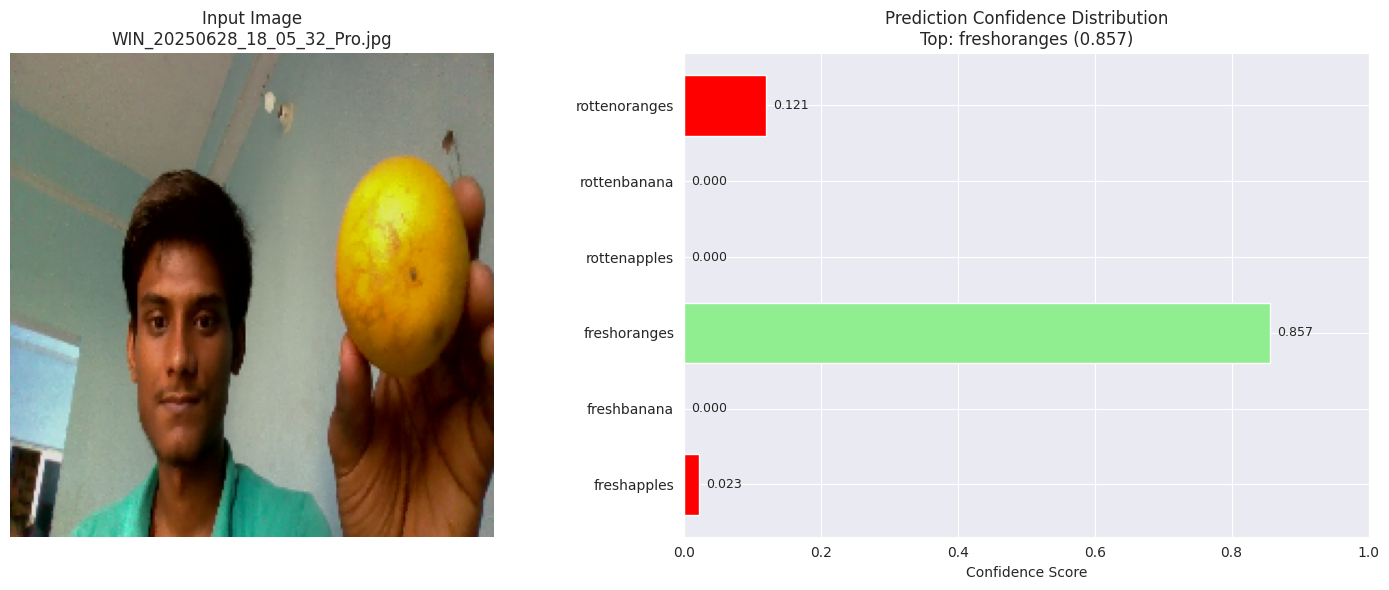


💡 RECOMMENDATIONS:
   ✅ High confidence prediction - likely accurate

CONFIDENCE LEVEL GUIDE:
🟢 Very High (90-100%): Extremely reliable
🟡 High (75-89%): Very reliable
🟠 Moderate (60-74%): Somewhat reliable
🔴 Low (40-59%): Questionable reliability
⚫ Very Low (0-39%): Not reliable


In [58]:
# Enhanced Test Script with Detailed Confidence Analysis
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

def interpret_confidence(confidence):
    """Interpret confidence level with descriptive text"""
    if confidence >= 0.9:
        return "Very High Confidence", "🟢"
    elif confidence >= 0.75:
        return "High Confidence", "🟡"
    elif confidence >= 0.6:
        return "Moderate Confidence", "🟠"
    elif confidence >= 0.4:
        return "Low Confidence", "🔴"
    else:
        return "Very Low Confidence", "⚫"

def display_all_predictions(predictions, class_labels):
    """Display all class predictions with confidence scores"""
    print("\n" + "="*50)
    print("DETAILED PREDICTION ANALYSIS")
    print("="*50)

    # Sort predictions by confidence (highest first)
    sorted_indices = np.argsort(predictions[0])[::-1]

    for i, idx in enumerate(sorted_indices):
        confidence = float(predictions[0][idx])
        class_name = class_labels[idx]
        conf_desc, emoji = interpret_confidence(confidence)

        # Create confidence bar visualization
        bar_length = int(confidence * 20)  # Scale to 20 characters
        bar = "█" * bar_length + "░" * (20 - bar_length)

        print(f"{i+1}. {class_name:<15} | {confidence:.3f} ({confidence*100:.1f}%) | {bar} {emoji}")

        if i == 0:  # Add extra info for top prediction
            print(f"   → {conf_desc}")

    print("="*50)

def test_model_with_confidence(model_path, test_image_path):
    """Enhanced model testing with detailed confidence analysis"""

    # Load model
    print("Loading model...")
    try:
        model = load_model(model_path, compile=False)
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        print("✅ Model loaded successfully!")
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return

    # Class labels (adjust according to your model)
    class_labels = ['freshapples', 'freshbanana', 'freshoranges',
                   'rottenapples', 'rottenbanana', 'rottenoranges']

    # Check if test image exists
    if not os.path.exists(test_image_path):
        print(f"❌ Test image not found: {test_image_path}")
        return

    try:
        # Load and preprocess image
        print(f"\nProcessing image: {os.path.basename(test_image_path)}")
        img = cv2.imread(test_image_path)

        if img is None:
            print("❌ Could not load image. Check if file is a valid image.")
            return

        img_resized = cv2.resize(img, (224, 224))
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
        img_normalized = img_rgb.astype('float32') / 255.0
        img_batch = np.expand_dims(img_normalized, axis=0)

        # Make prediction
        print("Making prediction...")
        predictions = model.predict(img_batch, verbose=0)

        # Get top prediction
        predicted_class_index = np.argmax(predictions[0])
        confidence = float(predictions[0][predicted_class_index])
        predicted_class = class_labels[predicted_class_index]
        conf_desc, emoji = interpret_confidence(confidence)

        # Display results
        print(f"\n🎯 TOP PREDICTION: {predicted_class}")
        print(f"📊 Confidence: {confidence:.3f} ({confidence*100:.1f}%)")
        print(f"📈 Assessment: {conf_desc} {emoji}")

        # Display all predictions
        display_all_predictions(predictions, class_labels)

        # Calculate prediction certainty metrics
        entropy = -np.sum(predictions[0] * np.log(predictions[0] + 1e-15))
        max_entropy = np.log(len(class_labels))
        uncertainty = entropy / max_entropy

        print(f"\n📊 ADDITIONAL METRICS:")
        print(f"   Prediction Uncertainty: {uncertainty:.3f} (lower is better)")
        print(f"   Entropy Score: {entropy:.3f}")

        # Determine if prediction is reliable
        if confidence >= 0.7 and uncertainty <= 0.5:
            reliability = "HIGH ✅"
        elif confidence >= 0.5 and uncertainty <= 0.7:
            reliability = "MODERATE ⚠️"
        else:
            reliability = "LOW ❌"

        print(f"   Overall Reliability: {reliability}")

        # Create enhanced visualization
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # Original image
        ax1.imshow(img_rgb)
        ax1.set_title(f"Input Image\n{os.path.basename(test_image_path)}", fontsize=12)
        ax1.axis('off')

        # Confidence bar chart
        colors = ['red' if conf < 0.4 else 'orange' if conf < 0.6 else 'yellow' if conf < 0.75 else 'lightgreen' if conf < 0.9 else 'darkgreen'
                 for conf in predictions[0]]

        bars = ax2.barh(range(len(class_labels)), predictions[0], color=colors)
        ax2.set_yticks(range(len(class_labels)))
        ax2.set_yticklabels(class_labels)
        ax2.set_xlabel('Confidence Score')
        ax2.set_title(f'Prediction Confidence Distribution\nTop: {predicted_class} ({confidence:.3f})')
        ax2.set_xlim(0, 1)

        # Add value labels on bars
        for i, (bar, conf) in enumerate(zip(bars, predictions[0])):
            ax2.text(conf + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{conf:.3f}', va='center', fontsize=9)

        plt.tight_layout()
        plt.show()

        # Provide recommendations based on confidence
        print(f"\n💡 RECOMMENDATIONS:")
        if confidence >= 0.8:
            print("   ✅ High confidence prediction - likely accurate")
        elif confidence >= 0.6:
            print("   ⚠️  Moderate confidence - consider additional validation")
        else:
            print("   ❌ Low confidence - recommend manual verification")
            print("   💡 Consider: better lighting, different angle, or image quality")

    except Exception as e:
        print(f"❌ Error during prediction: {e}")

# Main execution
if __name__ == "__main__":
    # Configuration
    model_path = 'my_fruit_vegetable_model.h5'
    test_image_path = '/content/drive/MyDrive/Test/freshoranges/WIN_20250628_18_05_32_Pro.jpg'

    # Run the enhanced test
    test_model_with_confidence(model_path, test_image_path)

    print(f"\n" + "="*50)
    print("CONFIDENCE LEVEL GUIDE:")
    print("🟢 Very High (90-100%): Extremely reliable")
    print("🟡 High (75-89%): Very reliable")
    print("🟠 Moderate (60-74%): Somewhat reliable")
    print("🔴 Low (40-59%): Questionable reliability")
    print("⚫ Very Low (0-39%): Not reliable")
    print("="*50)